In [2]:
import torch
import torchvision
import torch.nn.functional as F

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

# 有 GPU 就用 GPU，没有就用 CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [3]:
device

device(type='cpu')

In [1]:

!rm -rf /home/featurize/.cache/matplotlib

import matplotlib
matplotlib.rc("font",family='SimHei') # 中文字体

In [2]:
plt.plot([1,2,3], [100,500,300])
plt.title('matplotlib中文字体测试', fontsize=25)
plt.xlabel('X轴', fontsize=15)
plt.ylabel('Y轴', fontsize=15)
plt.show()

NameError: name 'plt' is not defined

In [6]:
idx_to_labels = np.load('idx_to_labels.npy', allow_pickle=True).item()

In [7]:
idx_to_labels

{0: 'Blackspot', 1: 'canker', 2: 'greening', 3: 'healthy', 4: 'melanose'}

In [8]:
# 如果你在没有GPU的环境下，可以将模型加载到CPU
model = torch.load('best-0.899.pth', map_location=torch.device('cpu'))
model = model.eval().to(device)

In [9]:
from torchvision import transforms
# 测试集图像预处理-RCTN：缩放、裁剪、转 Tensor、归一化
test_transform = transforms.Compose([transforms.Resize(256),
                                     transforms.CenterCrop(224),
                                     transforms.ToTensor(),
                                     transforms.Normalize(
                                         mean=[0.485, 0.456, 0.406], 
                                         std=[0.229, 0.224, 0.225])
                                    ])

In [10]:
from PIL import Image

In [11]:
img_path = 'HLB.png'
img_pil = Image.open(img_path)
np.array(img_pil).shape

(542, 332, 3)

In [12]:
input_img = test_transform(img_pil) # 预处理

In [13]:
input_img.shape

torch.Size([3, 224, 224])

In [14]:
input_img = input_img.unsqueeze(0).to(device)

In [15]:
input_img.shape

torch.Size([1, 3, 224, 224])

In [16]:
# 执行前向预测，得到所有类别的 logit 预测分数
pred_logits = model(input_img) 

In [17]:
pred_logits

tensor([[-0.6684, -0.6441,  0.4234, -2.5858, -2.8704]],
       grad_fn=<AddmmBackward0>)

In [18]:
pred_softmax = F.softmax(pred_logits, dim=1) # 对 logit 分数做 softmax 运算

In [19]:
pred_softmax

tensor([[0.1900, 0.1947, 0.5663, 0.0279, 0.0210]], grad_fn=<SoftmaxBackward0>)

findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'SimHei' not found.
/Users/liubaozhang/opt/anaconda3/envs/torch/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/liubaozhang/opt/anaconda3/envs/torch/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/liubaozhang/opt/anaconda3/envs/torch/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaV

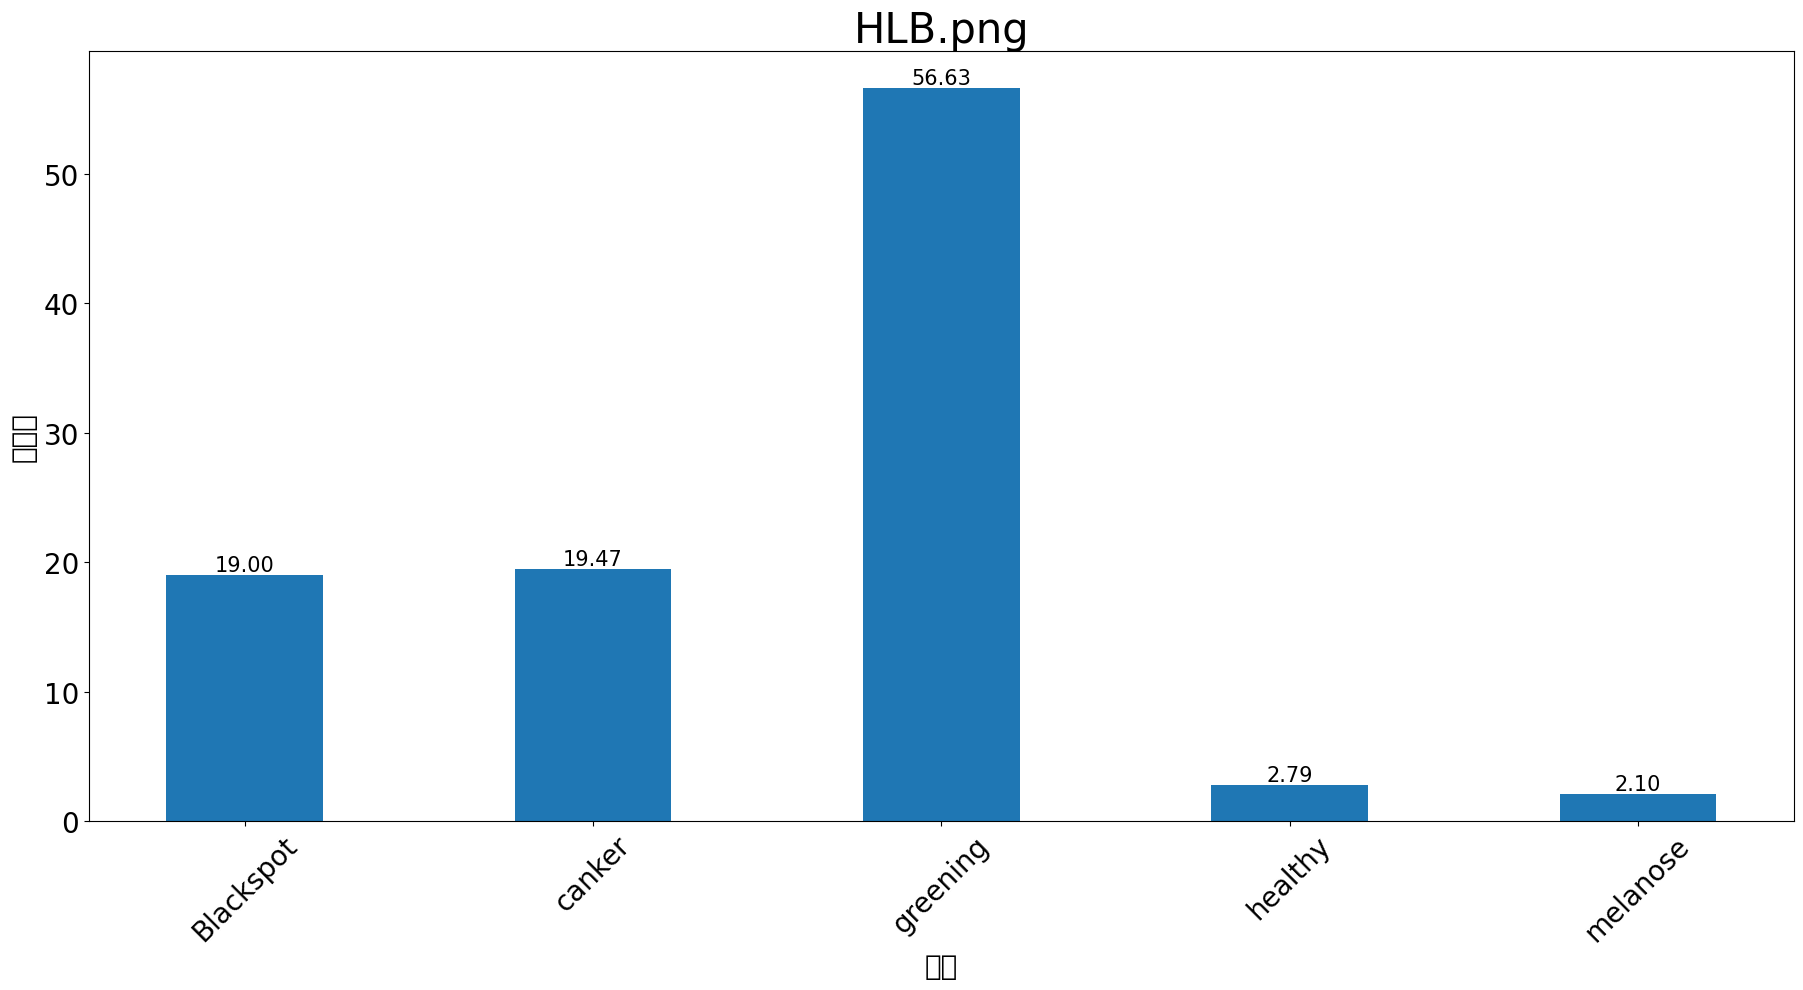

In [20]:
plt.figure(figsize=(22, 10))

x = idx_to_labels.values()
y = pred_softmax.cpu().detach().numpy()[0] * 100
width = 0.45 # 柱状图宽度

ax = plt.bar(x, y, width)

plt.bar_label(ax, fmt='%.2f', fontsize=15) # 置信度数值
plt.tick_params(labelsize=20) # 设置坐标文字大小

plt.title(img_path, fontsize=30)
plt.xticks(rotation=45) # 横轴文字旋转
plt.xlabel('类别', fontsize=20)
plt.ylabel('置信度', fontsize=20)
plt.show()

In [21]:
n = 2
top_n = torch.topk(pred_softmax, n) # 取置信度最大的 n 个结果
pred_ids = top_n[1].cpu().detach().numpy().squeeze() # 解析出类别
confs = top_n[0].cpu().detach().numpy().squeeze() # 解析出置信度

In [22]:
pred_ids

array([2, 1])

In [23]:
confs


array([0.56628233, 0.19472748], dtype=float32)